In [1]:
from datetime import datetime, timedelta

now = datetime.now()
print(f"Current date and time: {now}")

Current date and time: 2025-12-25 07:31:57.645419


In [2]:
N = 5000
time_idx = [float(i) for i in range(N)]

In [3]:
p1_peak = 5
p2_peak = 7
p1 = 24*2
p2 = 24*7

In [4]:
import numpy as np
weekly_omega = [(2*np.pi* t)/(p1) for t in time_idx]
monthly_omega = [(2*np.pi* t)/(p2) for t in time_idx]
weekly_vals = [p1_peak*np.sin(w) for w in weekly_omega]
monthly_vals = [p2_peak*np.sin(w) for w in monthly_omega]

In [5]:
level = [20 for i in range(N)]

In [6]:
from scipy.stats import norm
# Generate 1000 samples from a standard normal distribution (mean=0, std=1)
noise = norm.rvs(loc=0, scale=0.5, size=N)


In [7]:
signal = np.array(level) + np.array(weekly_vals) + np.array(monthly_vals) + np.array(noise)

In [8]:
time_vals = [now + timedelta(hours=i) for i in range(N)]

In [9]:
import pandas as pd
data = {"time": time_vals, "signal": signal}
df = pd.DataFrame.from_dict(data)

In [10]:
df

,time,signal
0,2025-12-25 07:31:57.645419,19.740650
1,2025-12-25 08:31:57.645419,21.525926
2,2025-12-25 09:31:57.645419,22.036987
3,2025-12-25 10:31:57.645419,23.730366
4,2025-12-25 11:31:57.645419,23.280209
...,...,...
4995,2026-07-21 10:31:57.645419,14.624984
4996,2026-07-21 11:31:57.645419,15.060006
4997,2026-07-21 12:31:57.645419,16.581797
4998,2026-07-21 13:31:57.645419,16.957700


In [11]:
series = df.signal
series.index = df.time

In [12]:
from visualization.series_visualizer import SeriesVisualizer

In [13]:
sv = SeriesVisualizer(series)

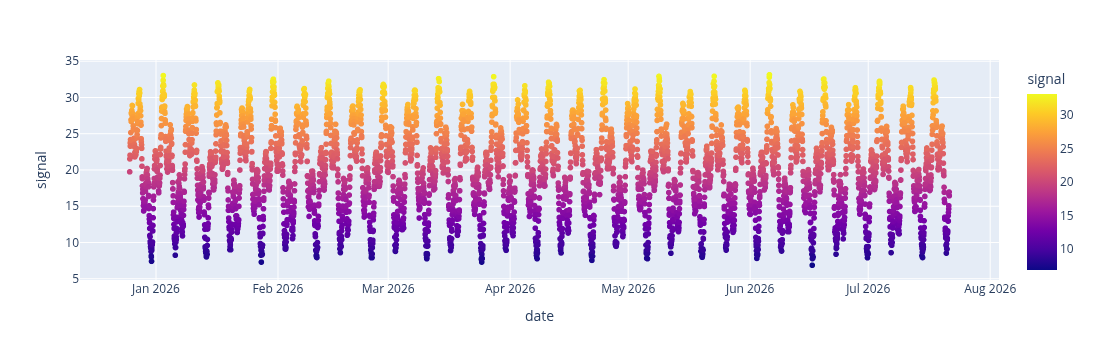

In [14]:
sv.getVisualization().show()

In [15]:
from periodicity.fft_analyzer import FFT_Analyzer

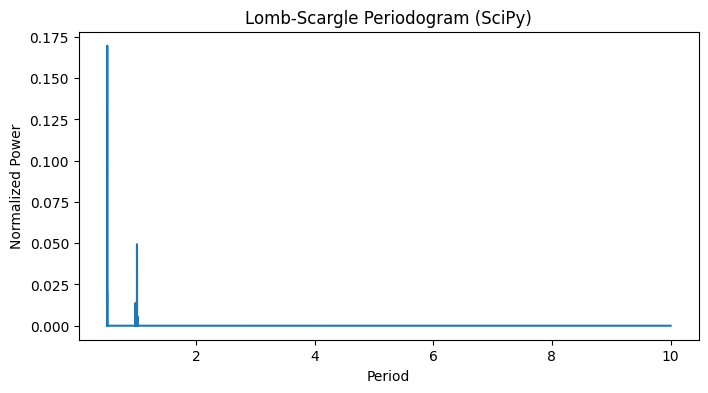

In [16]:
ffta = FFT_Analyzer(series)
ffta.plot()

<Axes: xlabel='time'>

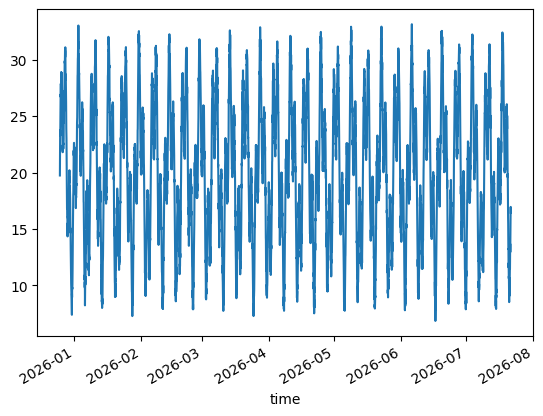

In [17]:
import matplotlib.pyplot as plt
df["signal"].plot()

In [18]:
from dataloader.synthetic_series_data_loader import SyntheticSeriesDataLoader

In [19]:
sdl = SyntheticSeriesDataLoader(None)

In [20]:
ss = sdl.get_series()

In [21]:
sv2 = SeriesVisualizer(ss)

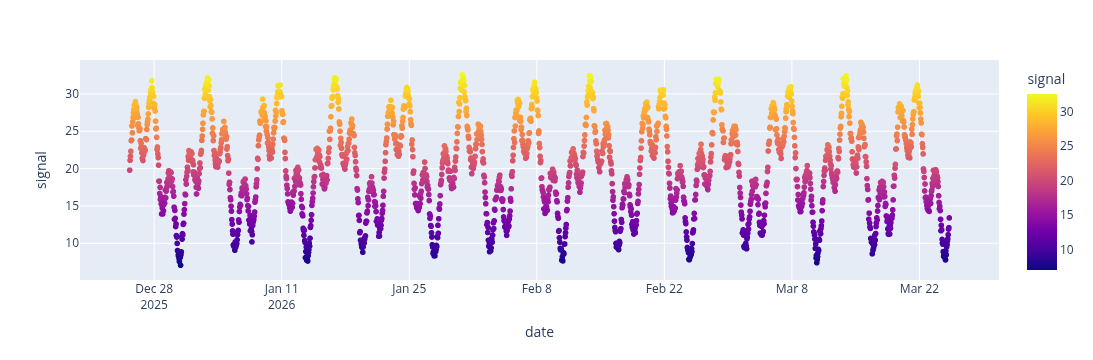

In [22]:
sv2.getVisualization().show()

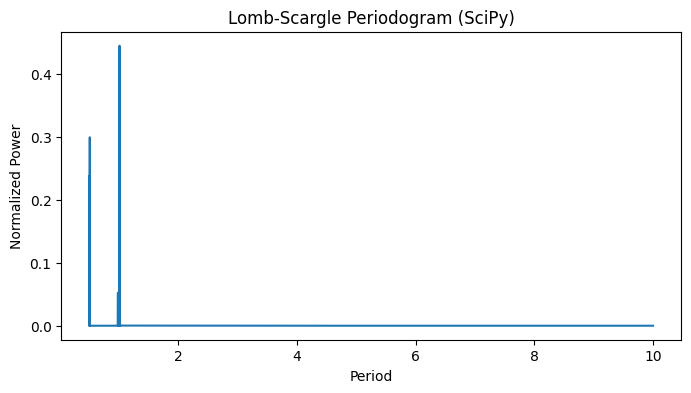

In [23]:
ffta2 = FFT_Analyzer(ss)
ffta2.plot()